In [4]:
%pip install sqlalchemy
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 35.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 41.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 37.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import sqlalchemy as db
from sqlalchemy import text, RowMapping, Sequence
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [6]:
DATABASE_NAME = "my_database.db"

engine = db.create_engine(f"sqlite:///{DATABASE_NAME}")

In [7]:
def import_file_to_db(file_path: str, table_name: str):
    if file_path.endswith(".csv"):
        df = pd.read_csv(file_path)
    elif file_path.endswith(".xlsx"):
        df = pd.read_excel(file_path)
    else:
        raise ValueError("Only .csv and .xlsx files are supported")

    df.to_sql(
        name=table_name,
        con=engine,
        if_exists="replace",
        index=False
    )

In [8]:
def execute_select(query: str) -> Sequence[RowMapping]:
    conn = engine.connect()

    try:
        result = conn.execute(text(query)).mappings().all()
        return result
    finally:
        conn.close()


def execute_change(query: str):
    conn = engine.connect()

    try:
        conn.execute(text(query))
        conn.commit()
    except Exception as error:
        conn.rollback()
        print("Error. Changes were rolled back")
        raise error
    finally:
        conn.close()

In [9]:
import_file_to_db(
    file_path="passengers.csv",
    table_name="passengers"
)

In [10]:
def get_chart_data(rows, x_key: str, y_key: str):
    x = [row[x_key] for row in rows]
    y = [row[y_key] for row in rows]

    return x, y

def plot_bar_from_rows(
    rows,
    x_key: str,
    y_key: str,
    title: str,
    x_label: str,
    y_label: str,
    y_min: int = 0,
    y_max: int = 100,
    value_suffix: str = "%"
):
    x, y = get_chart_data(rows, x_key, y_key)

    plt.figure(figsize=(8, 5))

    bars = plt.bar(x, y)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.ylim(y_min, y_max)

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}{value_suffix}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()
    
    def plot_line_from_rows(
        rows,
        x_key: str,
        y_key: str,
        title: str,
        x_label: str,
        y_label: str,
        y_min: int = 0,
        y_max: int = 100,
        value_suffix: str = "%",
        x_rotation: int = 0
    ):
        x, y = get_chart_data(rows, x_key, y_key)

        plt.figure(figsize=(8, 5))

        plt.plot(x, y, marker="o")

        plt.title(title)
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.ylim(y_min, y_max)
        plt.xticks(rotation=x_rotation)

        for i in range(len(x)):
            plt.text(
                x[i],
                y[i],
                f"{y[i]:.2f}{value_suffix}",
                ha="center",
                va="bottom"
            )

        plt.tight_layout()
        plt.show()

    def plot_multi_line_from_rows(
        rows,
        group_key: str,
        x_key: str,
        y_key: str,
        title: str,
        x_label: str,
        y_label: str,
        y_min: int = 0,
        y_max: int = 100,
        value_suffix: str = "%",
        x_rotation: int = 0
    ):
        groups = {}

        for row in rows:
            group = row[group_key]

            if group not in groups:
                groups[group] = {
                    "x": [],
                    "y": []
                }

            groups[group]["x"].append(row[x_key])
            groups[group]["y"].append(row[y_key])

        plt.figure(figsize=(8, 5))

        for group, values in groups.items():
            plt.plot(
                values["x"],
                values["y"],
                marker="o",
                label=str(group)
            )

            for i in range(len(values["x"])):
                plt.text(
                    values["x"][i],
                    values["y"][i],
                    f'{values["y"][i]:.2f}{value_suffix}',
                    ha="center",
                    va="bottom"
                )

        plt.title(title)
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.ylim(y_min, y_max)
        plt.xticks(rotation=x_rotation)
        plt.legend()

        plt.tight_layout()
        plt.show()

In [11]:
# сколько выжило пассажиров в общем?
survived = execute_select("""
SELECT 
    CASE 
        WHEN Survived = 0 THEN 'Погиб'
        WHEN Survived = 1 THEN 'Выжил'
    END as status,
    count(PassengerId) as count
FROM passengers
GROUP BY Survived
""")

survived

[{'status': 'Погиб', 'count': 486}, {'status': 'Выжил', 'count': 306}]

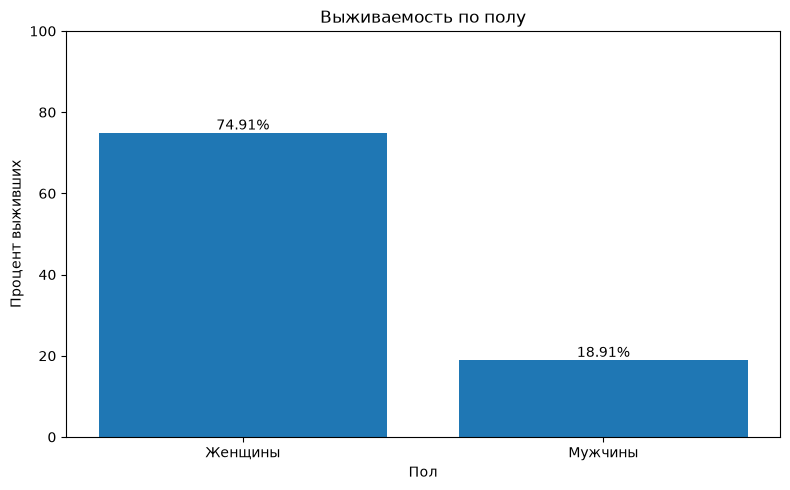

In [12]:
# выживаемость по полу?

survived_by_sex = execute_select("""
SELECT 
    CASE 
        WHEN Sex = 1 THEN 'Мужчины'
        WHEN Sex = 0 THEN 'Женщины'
    END as sex,
    COUNT(PassengerId) AS total,
    COUNT(PassengerId) FILTER (WHERE Survived = 1) as survived,
    ROUND(COUNT(PassengerId) FILTER (WHERE Survived = 1) * 100.0 / COUNT(PassengerId), 2) as survival_percent
FROM passengers
GROUP BY Sex
ORDER BY survival_percent desc
""")

survived_by_sex

plot_bar_from_rows(
    rows=survived_by_sex,
    x_key="sex",
    y_key="survival_percent",
    title="Выживаемость по полу",
    x_label="Пол",
    y_label="Процент выживших"
)


In [13]:
# выживаемость по классу билета?

survived_by_class = execute_select("""
SELECT
    CASE
        WHEN Pclass_1 = 1 THEN 1
        WHEN Pclass_2 = 1 THEN 2
        WHEN Pclass_3 = 1 THEN 3
        ELSE NULL
    END AS pclass,
    COUNT(PassengerId) AS total,
    SUM(Survived) AS survived,
    ROUND(AVG(Survived) * 100, 2) AS survival_percent
FROM passengers
GROUP BY pclass
ORDER BY survival_percent desc
""")

survived_by_class

plot_line_from_rows(
    rows=survived_by_class,
    x_key="pclass",
    y_key="survival_percent",
    title="Выживаемость по классу билета",
    x_label="Класс билета",
    y_label="Процент выживших"
)

NameError: name 'plot_line_from_rows' is not defined

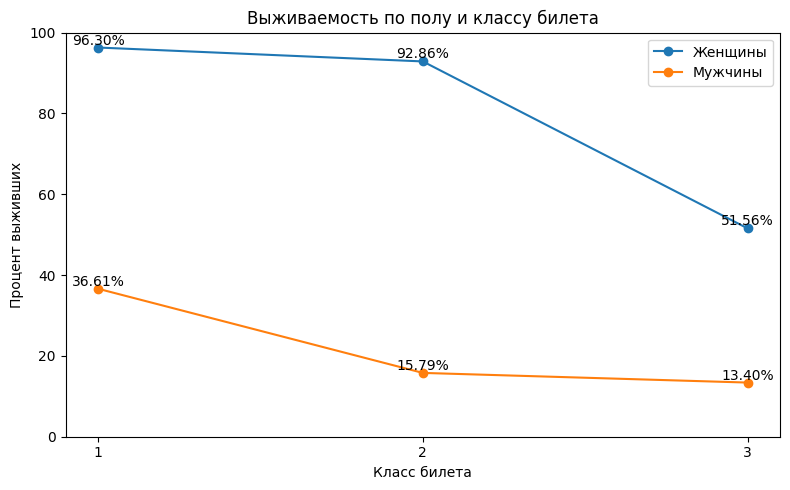

In [ ]:
# выживаемость по полу и классу билета?

survived_by_class_and_sex = execute_select("""
SELECT
    CASE 
        WHEN Sex = 1 THEN 'Мужчины'
        WHEN Sex = 0 THEN 'Женщины'
    END as sex,
    CASE
        WHEN Pclass_1 = 1 THEN 1
        WHEN Pclass_2 = 1 THEN 2
        WHEN Pclass_3 = 1 THEN 3
        ELSE NULL
    END AS pclass,
    COUNT(PassengerId) AS total,
    SUM(Survived) AS survived,
    ROUND(AVG(Survived) * 100, 2) AS survival_percent
FROM passengers
GROUP BY sex, pclass
ORDER BY survival_percent desc
""")

survived_by_class_and_sex

plot_multi_line_from_rows(
    rows=survived_by_class_and_sex,
    group_key="sex",
    x_key="pclass",
    y_key="survival_percent",
    title="Выживаемость по полу и классу билета",
    x_label="Класс билета",
    y_label="Процент выживших"
)

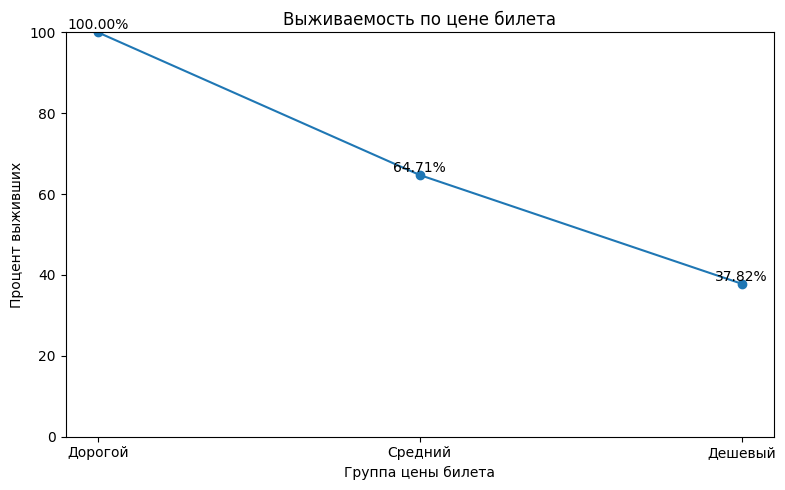

In [ ]:
# выживаемость по цене билета?

survived_by_fare = execute_select("""
SELECT
    CASE
        WHEN Fare < 0.35 THEN 'Дешевый'
        WHEN Fare < 0.7 THEN 'Средний'
        WHEN Fare <= 1 THEN 'Дорогой'
        ELSE NULL
    END AS fare_group,
    COUNT(PassengerId) AS total,
    SUM(Survived) AS survived,
    ROUND(AVG(Survived) * 100, 2) AS survival_percent
FROM passengers
GROUP BY fare_group
ORDER BY survival_percent desc
""")

survived_by_fare

plot_line_from_rows(
    rows=survived_by_fare,
    x_key="fare_group",
    y_key="survival_percent",
    title="Выживаемость по цене билета",
    x_label="Группа цены билета",
    y_label="Процент выживших"
)

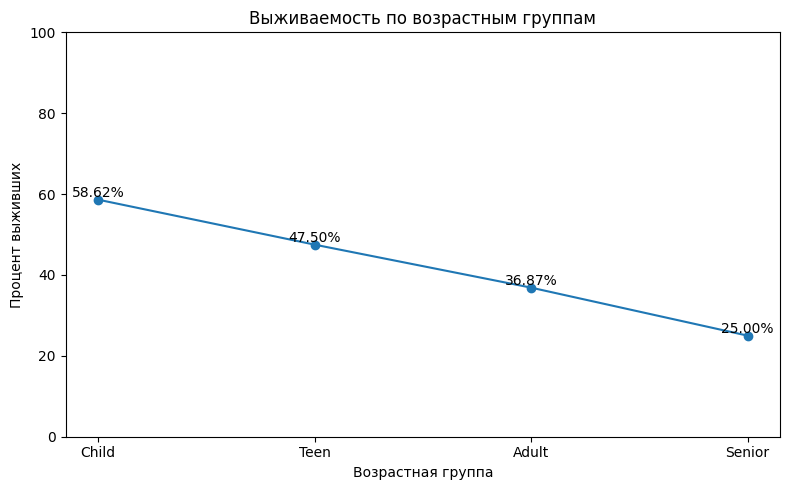

In [ ]:
# выживаемость по возрастным группам?

survived_by_age = execute_select("""
SELECT
    CASE
        WHEN Age < 0.15 THEN 'Child'
        WHEN Age >= 0.15 AND Age < 0.225 THEN 'Teen'
        WHEN Age >= 0.225 AND Age < 0.75 THEN 'Adult'
        WHEN Age >= 0.75 THEN 'Senior'
        ELSE 'Unknown'
    END AS age_group,
    COUNT(PassengerId) AS total,
    SUM(Survived) AS survived,
    ROUND(AVG(Survived) * 100, 2) AS survival_percent
FROM passengers
GROUP BY age_group
ORDER BY survival_percent desc
""")

survived_by_age

plot_line_from_rows(
    rows=survived_by_age,
    x_key="age_group",
    y_key="survival_percent",
    title="Выживаемость по возрастным группам",
    x_label="Возрастная группа",
    y_label="Процент выживших",
)

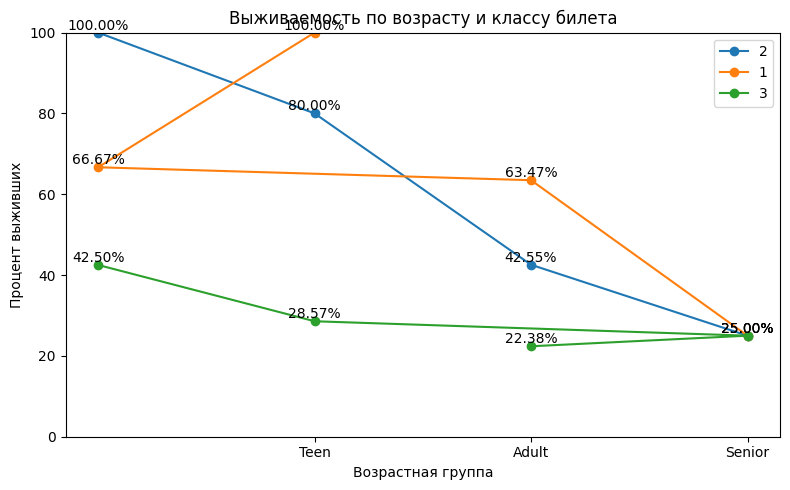

In [ ]:
# выживаемость по возрастным группам и классу билета?

survived_by_age_and_class = execute_select("""
SELECT
    age_group,
    pclass,
    COUNT(PassengerId) AS total,
    SUM(Survived) AS survived,
    ROUND(AVG(Survived) * 100, 2) AS survival_percent
FROM (
    SELECT
        PassengerId,
        Survived,

    CASE
        WHEN Age < 0.15 THEN 'Child'
        WHEN Age >= 0.15 AND Age < 0.225 THEN 'Teen'
        WHEN Age >= 0.225 AND Age < 0.75 THEN 'Adult'
        WHEN Age >= 0.75 THEN 'Senior'
        ELSE 'Unknown'
    END AS age_group,

    CASE
        WHEN Pclass_1 = 1 THEN 1
        WHEN Pclass_2 = 1 THEN 2
        WHEN Pclass_3 = 1 THEN 3
        ELSE NULL
    END AS pclass

    FROM passengers
)
GROUP BY age_group, pclass
ORDER BY survival_percent desc
""")

survived_by_age_and_class

plot_multi_line_from_rows(
    rows=survived_by_age_and_class,
    group_key="pclass",
    x_key="age_group",
    y_key="survival_percent",
    title="Выживаемость по возрасту и классу билета",
    x_label="Возрастная группа",
    y_label="Процент выживших",
)

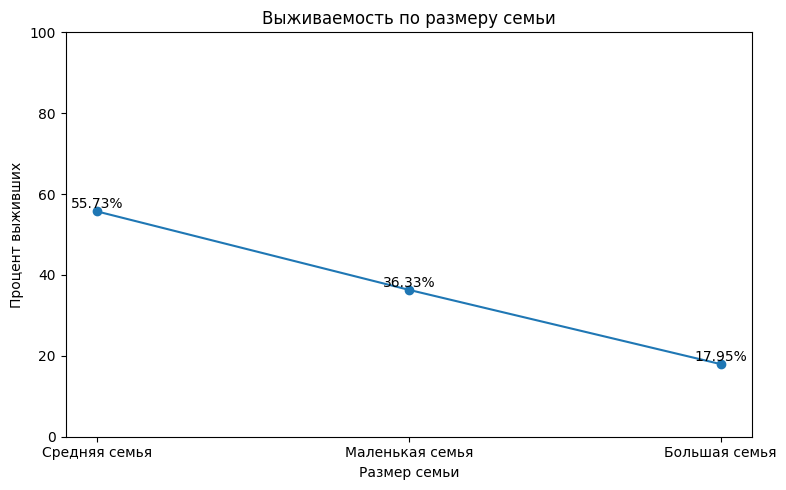

In [ ]:
# выживаемость по размеру семьи?

survived_by_family_size = execute_select("""
SELECT
    CASE
        WHEN Family_size < 0.20 THEN 'Маленькая семья'
        WHEN Family_size < 0.50 THEN 'Средняя семья'
        WHEN Family_size >= 0.50 THEN 'Большая семья'
        ELSE 'Unknown'
    END AS family_group,
    COUNT(PassengerId) AS total,
    SUM(Survived) AS survived_passengers,
    ROUND(AVG(Survived) * 100, 2) AS survival_percent
FROM passengers
GROUP BY family_group
ORDER BY survival_percent desc
""")

survived_by_family_size

plot_line_from_rows(
    rows=survived_by_family_size,
    x_key="family_group",
    y_key="survival_percent",
    title="Выживаемость по размеру семьи",
    x_label="Размер семьи",
    y_label="Процент выживших",
)

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

X, y = load_iris(return_X_y=True)
clf = LogisticRegression(random_state=0).fit(X, y)
clf.predict(X[:2, :])
clf.predict_proba(X[:2, :])
clf.score(X, y)